# Dates — date-source coverage, enrichment cascade and polity-of-citizenship age
Built on `humans_clean_v2.duckdb`: dates are either the Wikidata property or an LLM reading of the English Wikipedia article.

In [1]:
import numpy as np
import polars as pl
import duckdb
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

SEED = 42
np.random.seed(SEED)

DB_PATH = '../data/cultura/humans_clean_v2.duckdb'
TODAY_YEAR = 2026
SUB_YEAR = ('day', 'month')
YEAR_OR_FINER = ('day', 'month', 'year')

pl.Config.set_tbl_rows(30)
pl.Config.set_fmt_str_lengths(80)

COLORS = {'main': '#5b8fc7', 'grid': '#ececec'}
FIGSIZE = (10, 4.6)

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': FIGSIZE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'axes.formatter.useoffset': False,
})
THOUSANDS = FuncFormatter(lambda x, _: f'{x:,.0f}')

In [2]:
con = duckdb.connect(DB_PATH, read_only=True)
con.sql("SET memory_limit='3GB'; SET threads=4;")
con.sql("CREATE TEMP MACRO from_llm(d) AS coalesce(d.field_provenance['year'].ai_answer.prompt_id = 'wikipedia_dates', false)")

## Load data
### Per-individual date flags
One boolean per date source, computed in DuckDB and grouped into flag combinations (`n` = individuals per combination), so the 13M rows never leave the database.
A date is `llm` when its provenance carries `prompt_id = 'wikipedia_dates'`, `wd` (Wikidata property) otherwise. Date lists hold at most one element in V2, checked below.

In [3]:
max_list_len = con.sql("""
    SELECT max(greatest(len(birth_date), len(death_date), len(floruit_date))) FROM individual
""").fetchone()[0]
assert max_list_len == 1, max_list_len

date_flags = []
for kind in ['birth', 'death', 'floruit']:
    d = f'{kind}_date[1]'
    for source, negate in [('wd', 'NOT'), ('llm', '')]:
        base = f'len({kind}_date) > 0 AND {negate} from_llm({d})'
        date_flags += [
            f'coalesce({base}, false) AS {kind}_{source}',
            f'coalesce({base} AND {d}.precision IN {SUB_YEAR}, false) AS {kind}_{source}_sub',
            f'coalesce({base} AND {d}.precision IN {YEAR_OR_FINER}, false) AS {kind}_{source}_year',
        ]

flag_combos = con.sql(f"""
    WITH dated_place AS (
        SELECT entity.qid AS qid,
               existence.inception.year IS NOT NULL AS has_inception,
               existence.dissolution.year IS NOT NULL AS has_dissolution
        FROM place
    ),
    citizenship AS (
        SELECT c.qid, bool_or(p.has_inception) AS cit_inception, bool_or(p.has_dissolution) AS cit_dissolution
        FROM (SELECT entity.qid AS qid, unnest(country_of_citizenship).entity.qid AS place_qid FROM individual) c
        JOIN dated_place p ON p.qid = c.place_qid
        GROUP BY 1
    ),
    works AS (
        SELECT iw.qid,
               bool_or(w.publication_date.year IS NOT NULL) AS pub,
               bool_or(w.publication_date.precision IN {SUB_YEAR}) AS pub_sub,
               bool_or(w.publication_date.precision IN {YEAR_OR_FINER}) AS pub_year,
               bool_or(w.inception.year IS NOT NULL) AS winc,
               bool_or(w.inception.precision IN {SUB_YEAR}) AS winc_sub,
               bool_or(w.inception.precision IN {YEAR_OR_FINER}) AS winc_year
        FROM individual_work iw JOIN work w ON w.entity.qid = iw.work_qid
        GROUP BY 1
    ),
    flags AS (
        SELECT {', '.join(date_flags)},
               i.works_period.first_year IS NOT NULL AS has_works_period,
               coalesce(c.cit_inception, false) AS cit_inception,
               coalesce(c.cit_dissolution, false) AS cit_dissolution,
               coalesce(bp.has_inception, false) AS bp_inception,
               coalesce(bp.has_dissolution, false) AS bp_dissolution,
               coalesce(dp.has_inception, false) AS dp_inception,
               coalesce(dp.has_dissolution, false) AS dp_dissolution,
               coalesce(w.pub, false) AS pub, coalesce(w.pub_sub, false) AS pub_sub, coalesce(w.pub_year, false) AS pub_year,
               coalesce(w.winc, false) AS winc, coalesce(w.winc_sub, false) AS winc_sub, coalesce(w.winc_year, false) AS winc_year
        FROM individual i
        LEFT JOIN citizenship c ON c.qid = i.entity.qid
        LEFT JOIN dated_place bp ON bp.qid = i.place_of_birth.entity.qid
        LEFT JOIN dated_place dp ON dp.qid = i.place_of_death.entity.qid
        LEFT JOIN works w ON w.qid = i.entity.qid
    )
    SELECT *, count(*) AS n FROM flags GROUP BY ALL
""").pl()

TOTAL_INDIVIDUALS = con.sql('SELECT count(*) FROM individual').fetchone()[0]
assert flag_combos['n'].sum() == TOTAL_INDIVIDUALS
print(f'individuals: {TOTAL_INDIVIDUALS:,}  |  flag combinations: {flag_combos.height:,}')
flag_combos.sort('n', descending=True).head()

individuals: 13,002,897  |  flag combinations: 4,402


birth_wd,birth_wd_sub,birth_wd_year,birth_llm,birth_llm_sub,birth_llm_year,death_wd,death_wd_sub,death_wd_year,death_llm,death_llm_sub,death_llm_year,floruit_wd,floruit_wd_sub,floruit_wd_year,floruit_llm,floruit_llm_sub,floruit_llm_year,has_works_period,cit_inception,cit_dissolution,bp_inception,bp_dissolution,dp_inception,dp_dissolution,pub,pub_sub,pub_year,winc,winc_sub,winc_year,n
bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,i64
false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,2146493
false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,true,false,false,false,false,false,false,true,true,true,false,false,false,1929128
true,true,true,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,true,false,false,false,false,false,false,false,false,false,false,false,1057897
true,false,true,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,1000368
true,true,true,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,true,false,true,false,false,false,false,false,false,false,false,false,624005


### Countries of citizenship with inception / dissolution
Individual counts come from `individual.country_of_citizenship`; dates from the `place` table. V2 stores a single inception and dissolution per place, so the old "earliest vs latest inception" split no longer exists.

In [4]:
country_polities = con.sql("""
    SELECT c.qid, p.entity.label_en AS name_en, count(*) AS n_individuals,
           any_value(p.existence.inception.year) AS inception_year,
           any_value(p.existence.dissolution.year) AS dissolved_year
    FROM (SELECT unnest(country_of_citizenship).entity.qid AS qid FROM individual) c
    LEFT JOIN place p ON p.entity.qid = c.qid
    GROUP BY c.qid, p.entity.label_en
""").pl()

assert country_polities['qid'].n_unique() == country_polities.height
print('shape:', country_polities.shape)
country_polities.sort('n_individuals', descending=True).head()

shape: (3640, 5)


qid,name_en,n_individuals,inception_year,dissolved_year
str,str,i64,i64,i64
"""Q30""","""United States""",659823,1776,null
"""Q142""","""France""",387185,1804,null
"""Q183""","""Germany""",325196,800,null
"""Q17""","""Japan""",252340,-659,null
"""Q145""","""United Kingdom""",233021,1921,null


In [5]:
con.close()

## Date-source coverage table
For each date source: share of all individuals (col 1) and the fraction of those reaching sub-year precision (col 2). Spans (places, citizenship) have no point-date precision and show `—`.
The old cross-verified-database and Wikidata-description rows are gone: V2 holds no such dates.

In [6]:
SPAN = '—'

def n_where(expr):
    return flag_combos.filter(expr)['n'].sum()

def point_row(label, flag):
    n, n_sub = n_where(pl.col(flag)), n_where(pl.col(f'{flag}_sub'))
    return label, n, f'{n_sub / n * 100:.2f}%' if n else SPAN

def span_row(label, flag):
    return label, n_where(pl.col(flag)), SPAN

sources = [
    point_row('Birth date — Wikidata property', 'birth_wd'),
    point_row('Death date — Wikidata property', 'death_wd'),
    point_row('Floruit date — Wikidata property', 'floruit_wd'),
    point_row('Birth date — Wikipedia article (LLM)', 'birth_llm'),
    point_row('Death date — Wikipedia article (LLM)', 'death_llm'),
    point_row('Floruit date — Wikipedia article (LLM)', 'floruit_llm'),
    span_row('Country of citizenship — dissolution', 'cit_dissolution'),
    span_row('Country of citizenship — inception', 'cit_inception'),
    span_row('Birthplace — inception', 'bp_inception'),
    span_row('Birthplace — dissolution', 'bp_dissolution'),
    span_row('Deathplace — inception', 'dp_inception'),
    span_row('Deathplace — dissolution', 'dp_dissolution'),
    point_row('Works — publication date', 'pub'),
    point_row('Works — inception date', 'winc'),
]

point_flags = [f'{k}_{s}' for k in ['birth', 'death', 'floruit'] for s in ['wd', 'llm']]
any_date = pl.any_horizontal(point_flags + ['cit_inception', 'cit_dissolution', 'bp_inception',
                                            'bp_dissolution', 'dp_inception', 'dp_dissolution', 'pub', 'winc'])
year_precise = pl.any_horizontal([f'{f}_year' for f in point_flags] + ['pub_year', 'winc_year'])
n_any_date, n_year_precise = n_where(any_date), n_where(year_precise)

date_source_coverage = pl.DataFrame(
    [{'source': s, 'pct_individuals': f'{n / TOTAL_INDIVIDUALS * 100:.2f}%', 'precision_note': note}
     for s, n, note in sources]
    + [{'source': 'TOTAL — at least one date',
        'pct_individuals': f'{n_any_date / TOTAL_INDIVIDUALS * 100:.2f}%',
        'precision_note': f'{n_year_precise / n_any_date * 100:.2f}% (year or finer)'}]
)
print(f'Total unique individuals: {TOTAL_INDIVIDUALS:,}')
date_source_coverage

Total unique individuals: 13,002,897


source,pct_individuals,precision_note
str,str,str
"""Birth date — Wikidata property""","""57.59%""","""62.97%"""
"""Death date — Wikidata property""","""27.16%""","""70.39%"""
"""Floruit date — Wikidata property""","""0.53%""","""2.04%"""
"""Birth date — Wikipedia article (LLM)""","""0.02%""","""0.00%"""
"""Death date — Wikipedia article (LLM)""","""0.01%""","""0.00%"""
"""Floruit date — Wikipedia article (LLM)""","""0.01%""","""0.00%"""
"""Country of citizenship — dissolution""","""7.63%""","""—"""
"""Country of citizenship — inception""","""42.72%""","""—"""
"""Birthplace — inception""","""14.92%""","""—"""


## Recursive cascade (each individual attributed to the first matching source)

In [7]:
ENRICHMENT_STEPS = [
    ('Birth/death/floruit date from a Wikidata property', pl.any_horizontal('birth_wd', 'death_wd', 'floruit_wd')),
    ('Birth/death/floruit year from the Wikipedia article (LLM)', pl.any_horizontal('birth_llm', 'death_llm', 'floruit_llm')),
    ('Works min/max dates from Wikidata', pl.col('has_works_period')),
    ('Country-of-citizenship span from Wikidata', pl.any_horizontal('cit_inception', 'cit_dissolution')),
    ('Birth/death place span from Wikidata', pl.any_horizontal('bp_inception', 'bp_dissolution', 'dp_inception', 'dp_dissolution')),
]

covered = pl.lit(False)
cascade_rows = []
for label, flag in ENRICHMENT_STEPS:
    added = n_where(flag & ~covered)
    covered = covered | flag
    cascade_rows.append({'step': label, 'added': added,
                         'added_pct': added / TOTAL_INDIVIDUALS * 100,
                         'cum_pct': n_where(covered) / TOTAL_INDIVIDUALS * 100})

cascade = pl.DataFrame(cascade_rows)
assert cascade['added'].sum() == n_where(covered)
cascade

step,added,added_pct,cum_pct
str,i64,f64,f64
"""Birth/death/floruit date from a Wikidata property""",7794340,59.943103,59.943103
"""Birth/death/floruit year from the Wikipedia article (LLM)""",4192,0.032239,59.975342
"""Works min/max dates from Wikidata""",2170371,16.691442,76.666784
"""Country-of-citizenship span from Wikidata""",869400,6.686202,83.352987
"""Birth/death place span from Wikidata""",18101,0.139207,83.492194


## Paper-ready markdown table

In [8]:
def fmt_pct(p):
    return '<0.1%' if 0 < p < 0.1 else f'{p:.2f}%'

print('| Method | Unique individuals dated | Cumulative coverage |')
print('|---|---:|---:|')
for row in cascade.iter_rows(named=True):
    print(f"| {row['step']} | +{fmt_pct(row['added_pct'])} | {row['cum_pct']:.2f}% |")
final_coverage = cascade[-1, 'cum_pct']
print(f'| **Total with date/period** | **{final_coverage:.2f}%** | **{final_coverage:.2f}%** |')

| Method | Unique individuals dated | Cumulative coverage |
|---|---:|---:|
| Birth/death/floruit date from a Wikidata property | +59.94% | 59.94% |
| Birth/death/floruit year from the Wikipedia article (LLM) | +<0.1% | 59.98% |
| Works min/max dates from Wikidata | +16.69% | 76.67% |
| Country-of-citizenship span from Wikidata | +6.69% | 83.35% |
| Birth/death place span from Wikidata | +0.14% | 83.49% |
| **Total with date/period** | **83.49%** | **83.49%** |


## Polity age weighted by individuals (inception → dissolution, or → today)
Caveat: V2 keeps one inception per place, and for some countries it is a founding date far in the past (Germany 800, Japan −659), whereas the old notebook used the most recent ("modern") inception. The right tail of Fig 1 is therefore heavier than before.

In [9]:
country_polities = country_polities.with_columns(
    pl.when(pl.col('dissolved_year').is_not_null())
      .then(pl.col('dissolved_year') - pl.col('inception_year'))
      .otherwise(TODAY_YEAR - pl.col('inception_year'))
      .alias('polity_age')
)

aged_polities = country_polities.filter(pl.col('polity_age').is_not_null())
print(f'polities: {country_polities.height:,} -> with an age: {aged_polities.height:,} '
      f'({100 * aged_polities.height / country_polities.height:.1f}%)')
print(f'negative ages (dissolution before inception): {aged_polities.filter(pl.col("polity_age") < 0).height}')
print(f'citizenship links covered: {aged_polities["n_individuals"].sum():,} of {country_polities["n_individuals"].sum():,}')
aged_polities.select('name_en', 'n_individuals', 'inception_year', 'dissolved_year', 'polity_age').sort('n_individuals', descending=True).head(10)

polities: 3,640 -> with an age: 1,572 (43.2%)
negative ages (dissolution before inception): 1
citizenship links covered: 6,009,628 of 6,052,502


name_en,n_individuals,inception_year,dissolved_year,polity_age
str,i64,i64,i64,i64
"""United States""",659823,1776,null,250
"""France""",387185,1804,null,222
"""Germany""",325196,800,null,1226
"""Japan""",252340,-659,null,2685
"""United Kingdom""",233021,1921,null,105
"""Spain""",175862,1516,null,510
"""Soviet Union""",173248,1922,1991,69
"""Italy""",151615,1861,null,165
"""Canada""",140125,1867,null,159


### Fig 1 — Cumulative share of individuals by polity age
Each citizenship link counts once (an individual with two countries counts twice).

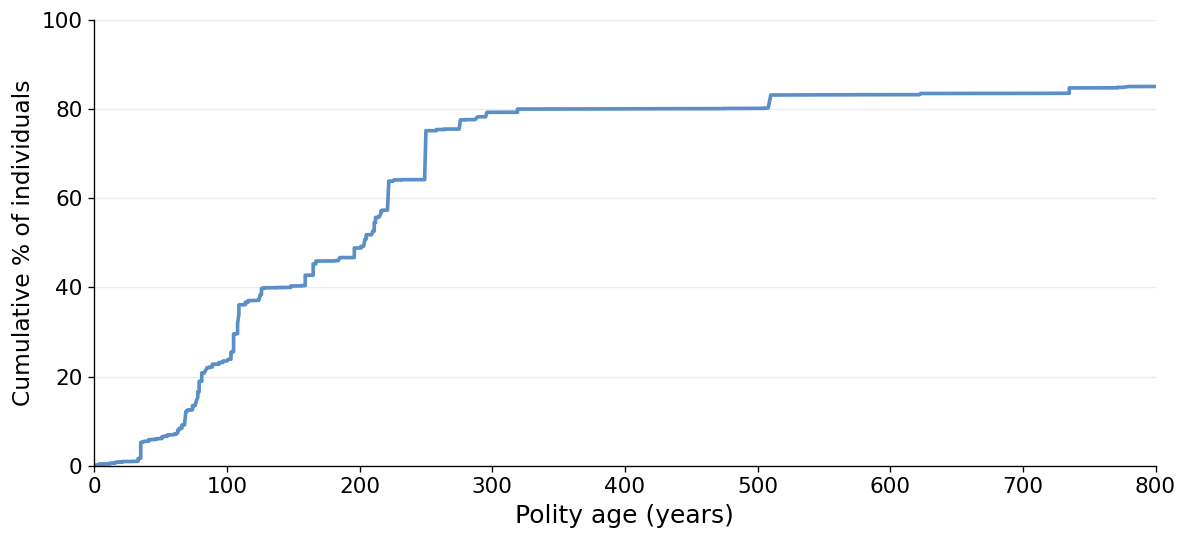

In [10]:
POLITY_AGE_X_MAX = 800

ages = aged_polities['polity_age'].to_numpy().astype(float)
weights = aged_polities['n_individuals'].to_numpy().astype(float)
order = np.argsort(ages)
cumulative_share = np.cumsum(weights[order]) / weights.sum()
xs = np.concatenate([[0], ages[order]])
ys = np.concatenate([[0], cumulative_share])

fig, ax = plt.subplots()
ax.plot(xs, 100 * ys, color=COLORS['main'], lw=2.2)
ax.set_xlim(0, POLITY_AGE_X_MAX)
ax.set_ylim(0, 100)
ax.set_xlabel('Polity age (years)')
ax.set_ylabel('Cumulative % of individuals', fontsize=14)
ax.grid(axis='y', color=COLORS['grid'], lw=0.8)
plt.tight_layout()
plt.show()